# A runnable walkthrough

Five minutes through the model, using only files committed to this repository — the
golden fixtures (fictional team names, real NFL players) and the logged backtest
results. **No league credentials, no network, any platform.**

Run it: `pip install -r requirements.txt jupyter`, then open this notebook from the
repo. Platform note: the byte-exact golden *hashes* are Windows-locked (see the
README), but nothing here compares hashes — on Linux/macOS the numbers below differ in
the last decimals and everything still works.

The full statistical specification is [`docs/METHODS.md`](METHODS.md); the audit trail
is [`AUDIT_SUMMARY.md`](../AUDIT_SUMMARY.md).

In [1]:
import json, os, sys
from pathlib import Path

# Run from the repo root wherever the notebook was opened from.
ROOT = Path.cwd()
if not (ROOT / "fantasy_sim").exists():
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

FX = ROOT / "tests" / "fixtures" / "golden" / "week01"
with open(FX / "player_baselines.json", encoding="utf-8") as f:
    baselines = json.load(f)
with open(FX / "live_rosters.json", encoding="utf-8") as f:
    rosters = json.load(f)
print(f"{len(baselines)} player baselines, {len(rosters)} teams:", ", ".join(sorted(rosters)))

964 player baselines, 8 teams: Cosmic Badgers, Crimson Marmots, Iron Wombats, Neon Walruses, Polar Yetis, Quantum Ferrets, Rocket Pandas, Turbo Llamas


## 1. A player-week is a distribution, not a number

Each player carries a projected mean and **two** standard deviations: aleatoric
(week-to-week noise, redrawn every week) and epistemic (how wrong the mean itself may
be, drawn **once per simulated season and held** — that's what carries projection
uncertainty into season outcomes instead of averaging it away).

Below: 2,000 simulated seasons × 14 weeks for one real player, illustratively
re-implemented in a few lines (the engine's exact path is `fantasy_sim/simulation.py`).
Each season's weekly scores wobble around a season-level mean that is *itself*
uncertain.

{'mean': 19.95, 'std_aleatoric': 8.84, 'std_epistemic': 12.57, 'pos': 'RB', 'team': 'DET'}


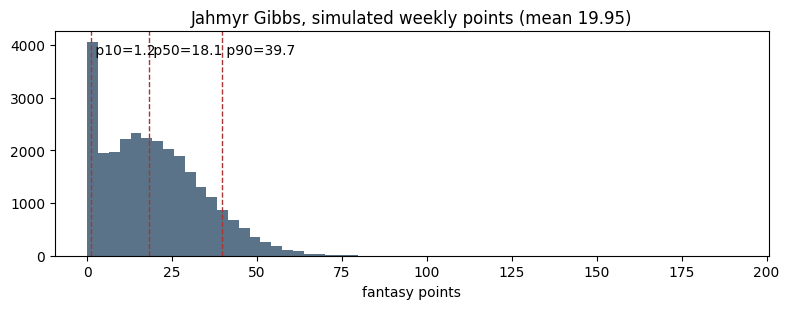

P(single week > 30) = 23.1%   P(week < 8) = 24.8%


In [2]:
p = baselines["Jahmyr Gibbs"]
print({k: p[k] for k in ("mean", "std_aleatoric", "std_epistemic", "pos", "team")})

rng = np.random.default_rng(7)
n_seasons, n_weeks = 2000, 14
season_mu = rng.normal(p["mean"], p["std_epistemic"], size=(n_seasons, 1))  # once per season
# lognormal parameterized to hit (season mean, aleatoric sd), floored at zero-ish means
mu = np.clip(season_mu, 0.5, None)
sigma2 = np.log1p((p["std_aleatoric"] / mu) ** 2)
weekly = rng.lognormal(np.log(mu) - sigma2 / 2, np.sqrt(sigma2), size=(n_seasons, n_weeks))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(weekly.ravel(), bins=60, color="#3d5a73", alpha=0.85)
q = np.percentile(weekly, [10, 50, 90])
for x, lbl in zip(q, ("p10", "p50", "p90")):
    ax.axvline(x, color="#a33", ls="--", lw=1); ax.text(x, ax.get_ylim()[1]*0.9, f" {lbl}={x:.1f}")
ax.set_title(f"Jahmyr Gibbs, simulated weekly points (mean {p['mean']})"); ax.set_xlabel("fantasy points")
fig.tight_layout(); plt.show()
print(f"P(single week > 30) = {(weekly > 30).mean():.1%}   P(week < 8) = {(weekly < 8).mean():.1%}")

## 2. Teammates move together (Gaussian copula)

A QB's big day and his WR1's big day are correlated; the engine couples same-team
players through a Gaussian copula with measured coefficients (re-confirmed on 391
players / 714 pooled pair-weeks). The QB–WR1 coefficient is 0.40:

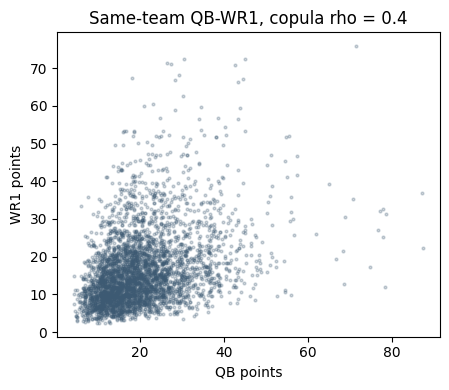

realized rank correlation: 0.36


In [3]:
from fantasy_sim.config import SIM_CONFIG
rho = SIM_CONFIG["CORRELATIONS"]["QB_WR1"]
cov = [[1, rho], [rho, 1]]
z = rng.multivariate_normal([0, 0], cov, size=4000)
from scipy.stats import norm
u = norm.cdf(z)                      # copula: uniform marginals, correlated
qb  = np.quantile(np.sort(rng.lognormal(np.log(18), 0.45, 4000)), u[:, 0])
wr1 = np.quantile(np.sort(rng.lognormal(np.log(14), 0.55, 4000)), u[:, 1])
fig, ax = plt.subplots(figsize=(4.6, 4))
ax.scatter(qb, wr1, s=4, alpha=0.25, color="#3d5a73")
ax.set_xlabel("QB points"); ax.set_ylabel("WR1 points")
ax.set_title(f"Same-team QB-WR1, copula rho = {rho}")
fig.tight_layout(); plt.show()
print(f"realized rank correlation: {np.corrcoef(qb, wr1)[0,1]:.2f}")

## 3. A hermetic mini-season, through the real engine

The test suite's golden sandbox isolates the actual, unmodified
`FantasySimulationEngine` onto the committed fixtures (and severs every live read).
Here: 100 simulated seasons from week 1 — small, so it runs in seconds; the production
number is 10,000.

In [4]:
from tests import golden_master as gm
from fantasy_sim.simulation import FantasySimulationEngine

with gm._sandbox("week01", batches=2, sims_per_batch=50):
    sim = FantasySimulationEngine()
    captured = {}
    def capture(*args, **kwargs):          # skip chart rendering; keep the numbers
        captured["wins"], captured["playoffs"] = args[0], args[2]
    sim.export_and_visualize = capture
    sim.run_simulation()

import pandas as pd
rows = [{"team": t, "exp_wins": round(float(np.mean(w)), 2),
         "playoff_pct": round(100 * float(np.mean(captured["playoffs"][t])), 1)}
        for t, w in captured["wins"].items()]
pd.DataFrame(rows).sort_values("exp_wins", ascending=False).reset_index(drop=True)

[INFO] Imputed whitelisted missing asset: Jordyn Tyson (Turbo Llamas)
[PRE-FLIGHT SUCCESS] 965 Projections Validated.

[>>>] EXECUTING 2 INDEPENDENT BATCHES (100 TOTAL RUNS)...


[SUCCESS] Markov simulation resolved across all batches. Rendering visual telemetry...


,team,exp_wins,playoff_pct
0,Polar Yetis,17.04,69.0
1,Neon Walruses,15.25,55.0
2,Turbo Llamas,14.56,55.0
3,Quantum Ferrets,14.23,51.0
4,Cosmic Badgers,14.02,57.0
5,Rocket Pandas,13.45,45.0
6,Iron Wombats,12.26,36.0
7,Crimson Marmots,11.19,32.0


## 4. Is any of it calibrated? (measured, not hoped)

Every commit's points-level backtest against the real 2025 season is logged. The
latest line — including the **naive baseline**: a projections-only static forecast on
identical rows, which the engine must beat to justify its machinery:

  n            240
  bias         -1.13
  bias_pct     -0.87
  mean_z       0.0537
  cover80      0.6542
  cover50      0.3583
  engine_mae   22.236
  naive_mae    26.555
  naive_bias   -17.771


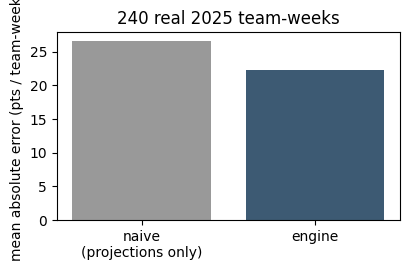

cover80 = 0.65 vs nominal 0.80 is a KNOWN under-dispersion, owned in METHODS §6 --
the 2026 pre-registered evaluation (SEASON_2026_EVALUATION.md) is the decisive test.


In [5]:
last = json.loads(open("data/logs/points_backtest.jsonl", encoding="utf-8")
                  .read().strip().splitlines()[-1])
o = last["overall"] if "overall" in last else last
keys = ["n", "bias", "bias_pct", "mean_z", "cover80", "cover50",
        "engine_mae", "naive_mae", "naive_bias"]
shown = {k: o[k] for k in keys if k in o}
for k, v in shown.items():
    print(f"  {k:12s} {v}")

fig, ax = plt.subplots(figsize=(4.2, 2.8))
ax.bar(["naive\n(projections only)", "engine"], [o["naive_mae"], o["engine_mae"]],
       color=["#999", "#3d5a73"])
ax.set_ylabel("mean absolute error (pts / team-week)")
ax.set_title("240 real 2025 team-weeks")
fig.tight_layout(); plt.show()
print("cover80 = 0.65 vs nominal 0.80 is a KNOWN under-dispersion, owned in METHODS §6 --")
print("the 2026 pre-registered evaluation (SEASON_2026_EVALUATION.md) is the decisive test.")

## Where to go next

- [`docs/METHODS.md`](METHODS.md) — the full specification and known limitations.
- [`AUDIT_SUMMARY.md`](../AUDIT_SUMMARY.md) — ~75 findings; what was fixed, measured-and-cleared, or honestly left open.
- [The live sanitized sample report](https://brandon-kimberly.github.io/2026-fantasy-football-simulation/sample/weekly_report_sample.html) — what a real weekly run produces.